# Laboratorio 14 — Regresión lineal múltiple

## Predicción de ventas mediante diferentes medios publicitarios

**Asignatura:** Analítica de Datos  
**Programa:** Ingeniería de Software  
**Universidad:** Universidad Cooperativa de Colombia  
**Docente:** Luis Miguel Gómez Meneses  


## Descripción

En este laboratorio construiremos un modelo de **regresión lineal múltiple** para estimar las ventas de un producto a partir de la inversión realizada en tres medios publicitarios:

- televisión (`TV`);
- radio (`radio`);
- prensa (`newspaper`).

La variable que queremos estimar es:

- ventas (`sales`).

El modelo tendrá la siguiente estructura:

$$
\widehat{\text{sales}}
=
\beta_0
+\beta_1(\text{TV})
+\beta_2(\text{radio})
+\beta_3(\text{newspaper})
$$

Cada coeficiente permitirá estimar el cambio en las ventas asociado con una variable publicitaria, manteniendo constantes las demás.

## Pregunta orientadora

**¿Mejora la estimación de las ventas cuando utilizamos simultáneamente las inversiones en televisión, radio y prensa?**

## Objetivos

- Construir un modelo de regresión lineal múltiple.
- Interpretar el intercepto y los coeficientes del modelo.
- Generar predicciones sobre datos no utilizados en el entrenamiento.
- Evaluar el modelo mediante \(R^2\), MAE, MSE y RMSE.
- Comparar el desempeño del modelo múltiple con el modelo lineal simple.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import statsmodels.api as sm
sns.set_theme(style="whitegrid")

## Carga del conjunto de datos

Utilizaremos nuevamente el conjunto de datos `Advertising.csv`.

Cada fila representa una observación y contiene la inversión realizada en diferentes medios publicitarios junto con las ventas obtenidas.

Las variables son:

- `TV`: inversión en publicidad por televisión, expresada en miles de dólares.
- `radio`: inversión en publicidad por radio, expresada en miles de dólares.
- `newspaper`: inversión en publicidad por prensa, expresada en miles de dólares.
- `sales`: ventas del producto, expresadas en miles de unidades.

En este laboratorio emplearemos las tres inversiones publicitarias como variables predictoras.

In [2]:
datos = pd.read_csv(
    "/content/Advertising.csv",
    index_col=0
)
print("Dimensiones del conjunto de datos:")
print(datos.shape)
print("\nColumnas:")
print(datos.columns.tolist())
print("\nPrimeras observaciones:")
display(datos.head())

Dimensiones del conjunto de datos:
(200, 4)

Columnas:
['TV', 'radio', 'newspaper', 'sales']

Primeras observaciones:


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Análisis de correlación entre las variables

Antes de construir el modelo de regresión múltiple, analizaremos la relación lineal entre las variables mediante una matriz de correlación de Pearson.

La matriz permitirá observar:

- la relación de `TV` con `sales`;
- la relación de `radio` con `sales`;
- la relación de `newspaper` con `sales`;
- las relaciones existentes entre las propias variables predictoras.

Los coeficientes de correlación toman valores entre \(-1\) y \(1\):

- valores cercanos a \(1\) indican una relación lineal positiva;
- valores cercanos a \(-1\) indican una relación lineal negativa;
- valores cercanos a \(0\) indican una relación lineal débil o inexistente.

Matriz de correlación:


,TV,radio,newspaper,sales
TV,1.000,0.055,0.057,0.782
radio,0.055,1.000,0.354,0.576
newspaper,0.057,0.354,1.000,0.228
sales,0.782,0.576,0.228,1.000


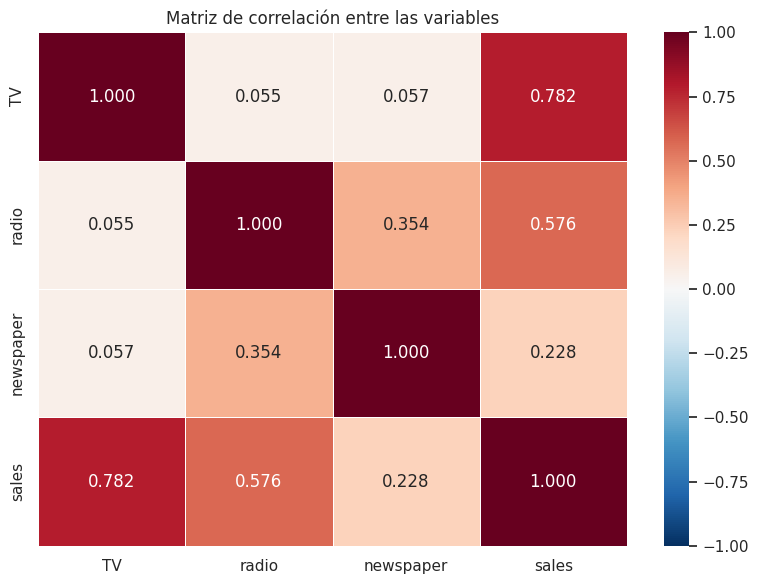

In [3]:
matriz_correlacion = datos.corr(method="pearson")
print("Matriz de correlación:")
display(matriz_correlacion.round(3))
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)
plt.title("Matriz de correlación entre las variables")
plt.tight_layout()
plt.show()

### Preguntas de análisis

- ¿Cuál variable publicitaria presenta la correlación lineal más fuerte con las ventas?

- ¿Cómo se interpreta la correlación de \(0.576\) entre `radio` y `sales`?

- ¿Qué indica la correlación de \(0.228\) entre `newspaper` y `sales`?

- ¿Se observan correlaciones altas entre las variables predictoras `TV`, `radio` y `newspaper`?

- ¿Debemos eliminar inmediatamente `newspaper` del modelo porque presenta una correlación débil con las ventas? Justifique su respuesta.

### Respuestas

Escriba aquí sus respuestas a partir de la matriz de correlación obtenida.

## Definición de las variables del modelo

En la regresión lineal múltiple utilizaremos tres variables predictoras:

$$
X=
\left[
\text{TV},
\text{radio},
\text{newspaper}
\right]
$$

La variable respuesta será:
$$
Y=\text{sales}
$$

Dividiremos los datos en dos conjuntos:

- **80 % para entrenamiento:** se utilizará para estimar los coeficientes del modelo.
- **20 % para prueba:** se utilizará para evaluar las predicciones en observaciones que el modelo no utilizó durante el entrenamiento.

Se empleará `random_state=42` para obtener una división reproducible y comparable con la utilizada en el modelo de regresión lineal simple.

In [4]:
X = datos[["TV", "radio", "newspaper"]]
y = datos["sales"]
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Dimensión de X:")
print(X.shape)
print("\nDimensión de y:")
print(y.shape)
print("\nObservaciones de entrenamiento:")
print(len(X_entrenamiento))
print("\nObservaciones de prueba:")
print(len(X_prueba))
print("\nDimensión de X_entrenamiento:")
print(X_entrenamiento.shape)
print("\nDimensión de X_prueba:")
print(X_prueba.shape)
print("\nVariables predictoras utilizadas:")
print(X.columns.tolist())

Dimensión de X:
(200, 3)

Dimensión de y:
(200,)

Observaciones de entrenamiento:
160

Observaciones de prueba:
40

Dimensión de X_entrenamiento:
(160, 3)

Dimensión de X_prueba:
(40, 3)

Variables predictoras utilizadas:
['TV', 'radio', 'newspaper']


## Entrenamiento del modelo de regresión lineal múltiple

Entrenaremos un modelo que relacione las ventas con las inversiones realizadas en televisión, radio y prensa.

La ecuación que queremos estimar es:

$$
\widehat{\text{sales}}
=
\beta_0
+\beta_1(\text{TV})
+\beta_2(\text{radio})
+\beta_3(\text{newspaper})
$$

El modelo calculará:

- un intercepto \(\beta_0\);
- un coeficiente para `TV`;
- un coeficiente para `radio`;
- un coeficiente para `newspaper`.

Cada coeficiente representa el cambio estimado en las ventas cuando su variable aumenta una unidad y las demás variables permanecen constantes.

In [5]:
modelo_multiple = LinearRegression()
modelo_multiple.fit(
    X_entrenamiento,
    y_entrenamiento
)
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_multiple.coef_
})
print(f"Intercepto: {modelo_multiple.intercept_:.4f}")
print("\nCoeficientes del modelo:")
display(coeficientes.round(4))
print("\nEcuación estimada:")
print(
    f"sales estimadas = {modelo_multiple.intercept_:.4f} "
    f"+ ({modelo_multiple.coef_[0]:.4f})(TV) "
    f"+ ({modelo_multiple.coef_[1]:.4f})(radio) "
    f"+ ({modelo_multiple.coef_[2]:.4f})(newspaper)"
)

Intercepto: 2.9791

Coeficientes del modelo:


,Variable,Coeficiente
0,TV,0.0447
1,radio,0.1892
2,newspaper,0.0028



Ecuación estimada:
sales estimadas = 2.9791 + (0.0447)(TV) + (0.1892)(radio) + (0.0028)(newspaper)


### Preguntas de análisis y respuestas

**¿Cómo se interpreta el intercepto \(2.9791\) en el contexto del modelo?**

Cuando las inversiones en televisión, radio y prensa son iguales a cero, el modelo estima unas ventas de:

$$
\widehat{\text{sales}}=2.9791
$$

Esto corresponde aproximadamente a **2 979 unidades vendidas**.

**¿Cómo se interpreta el coeficiente \(0.0447\) correspondiente a la inversión en televisión?**

Manteniendo constantes las inversiones en radio y prensa, por cada mil dólares adicionales invertidos en televisión, las ventas estimadas aumentan aproximadamente:

$$
0.0447\text{ miles de unidades}
$$

Esto corresponde aproximadamente a **44.7 unidades vendidas**.

**¿Cómo se interpreta el coeficiente \(0.1892\) correspondiente a la inversión en radio?**

Manteniendo constantes las inversiones en televisión y prensa, por cada mil dólares adicionales invertidos en radio, las ventas estimadas aumentan aproximadamente:

$$
0.1892\text{ miles de unidades}
$$

Esto corresponde aproximadamente a **189.2 unidades vendidas**.



**¿Cuál medio publicitario presenta el mayor cambio estimado en las ventas por cada mil dólares adicionales invertidos?**

La inversión en radio presenta el coeficiente más alto:

$$
\beta_{\text{radio}}=0.1892
$$

Por tanto, dentro de este modelo, radio presenta el mayor aumento estimado en las ventas por cada mil dólares adicionales invertidos, manteniendo constantes las demás variables.

**¿Podemos concluir solamente con los coeficientes que `newspaper` debe eliminarse del modelo? Justifique su respuesta.**

No. El coeficiente de `newspaper` es pequeño:
$$
\beta_{\text{newspaper}}=0.0028
$$

Sin embargo, el tamaño del coeficiente no permite determinar por sí solo si la variable aporta información estadísticamente significativa. Debemos examinar su error estándar, estadístico \(t\) y valor \(p\).

## Significancia estadística de los coeficientes

Hasta ahora utilizamos la regresión lineal múltiple para obtener la siguiente ecuación:

$$
\widehat{\text{sales}}
=
\beta_0
+\beta_1(\text{TV})
+\beta_2(\text{radio})
+\beta_3(\text{newspaper})
$$

Los coeficientes estimados indican la dirección y el tamaño del cambio esperado en las ventas. Sin embargo, el valor de un coeficiente no permite determinar por sí solo si la variable aporta evidencia estadística al modelo.

En esta sección analizaremos la **significancia estadística de cada coeficiente**. El objetivo es establecer si cada inversión publicitaria mantiene una asociación lineal con las ventas después de controlar las demás variables incluidas en el modelo.

### Hipótesis estadísticas

Para cada variable predictora evaluaremos las siguientes hipótesis:

$$
H_0:\beta_j=0
$$

$$
H_1:\beta_j\neq 0
$$

La hipótesis nula \(H_0\) plantea que el coeficiente poblacional de la variable es igual a cero. Esto significa que, después de controlar las demás inversiones publicitarias, no existe evidencia suficiente de una asociación lineal entre esa variable y las ventas.

La hipótesis alternativa \(H_1\) plantea que el coeficiente poblacional es diferente de cero. Esto indicaría que la variable presenta una asociación lineal estadísticamente significativa con las ventas, manteniendo constantes los demás predictores.

Utilizaremos un nivel de significancia de:

$$
\alpha=0.05
$$

La decisión se tomará mediante el valor \(p\):

- si \(p<0.05\), rechazamos \(H_0\) y consideramos que la variable es estadísticamente significativa;
- si \(p\geq 0.05\), no rechazamos \(H_0\) porque no existe evidencia estadística suficiente para afirmar que su coeficiente es diferente de cero.

No rechazar \(H_0\) no demuestra que el efecto sea exactamente cero. Significa que los datos analizados no proporcionan evidencia suficiente para identificar un aporte lineal de esa variable dentro del modelo.


### Información que mostrará la tabla

La tabla presentará los siguientes resultados para el intercepto y para cada variable predictora.

#### Coeficiente

Representa el cambio estimado en las ventas cuando la variable predictora aumenta una unidad y las demás variables permanecen constantes.

En este conjunto de datos, una unidad de inversión representa mil dólares y las ventas están expresadas en miles de unidades.

Por ejemplo, el coeficiente de `TV` representa el cambio estimado en las ventas por cada mil dólares adicionales invertidos en televisión, manteniendo constantes las inversiones en radio y prensa.

La fila denominada `const` corresponde al intercepto \(\beta_0\). Este representa las ventas estimadas cuando las inversiones en televisión, radio y prensa son iguales a cero.


#### Error estándar

El error estándar mide la incertidumbre asociada con la estimación de cada coeficiente.

Un error estándar pequeño en relación con el coeficiente indica una estimación más precisa. Un error estándar grande indica mayor incertidumbre sobre el valor real del coeficiente poblacional.


#### Estadístico \(t\)

El estadístico \(t\) compara el coeficiente estimado con su error estándar:

$$
t=
\frac{\text{coeficiente estimado}}
{\text{error estándar}}
$$

Un valor de \(t\) cercano a cero indica que el coeficiente estimado es pequeño en comparación con su incertidumbre.

Un valor de \(t\) con una magnitud grande, positiva o negativa, proporciona mayor evidencia de que el coeficiente poblacional es diferente de cero.


#### Valor \(p\)

El valor \(p\) permite tomar la decisión sobre la hipótesis nula.

Representa la probabilidad de obtener un resultado tan extremo como el observado si el coeficiente poblacional fuera realmente igual a cero.

Un valor \(p\) pequeño proporciona evidencia contra \(H_0\).

Cuando la tabla muestra un valor \(p\) igual a `0.0000`, no significa que la probabilidad sea exactamente cero. Significa que el valor es muy pequeño y fue redondeado a cuatro decimales.


#### Intervalo de confianza del 95 %

El intervalo de confianza presenta un rango de valores compatibles con los datos para el coeficiente poblacional.

Se mostrará mediante dos límites:

- límite inferior del 95 %;
- límite superior del 95 %.

Si el intervalo de confianza no contiene el valor cero, el resultado coincide normalmente con un valor \(p<0.05\), y el coeficiente se considera estadísticamente significativo.

Si el intervalo contiene el valor cero, el coeficiente podría ser negativo, nulo o positivo. En ese caso, normalmente no se rechaza la hipótesis nula.


### Datos utilizados

El análisis se realizará únicamente con las 160 observaciones del conjunto de entrenamiento.

Las 40 observaciones del conjunto de prueba permanecerán separadas y se utilizarán posteriormente para evaluar la capacidad predictiva del modelo.

`statsmodels` estimará la misma ecuación calculada anteriormente con `LinearRegression`, pero añadirá las medidas de incertidumbre y las pruebas estadísticas necesarias para analizar cada coeficiente.

In [6]:
X_entrenamiento_sm = sm.add_constant(X_entrenamiento)
modelo_estadistico = sm.OLS(
    y_entrenamiento,
    X_entrenamiento_sm
).fit()
tabla_significancia = pd.DataFrame({
    "Coeficiente": modelo_estadistico.params,
    "Error estándar": modelo_estadistico.bse,
    "Estadístico t": modelo_estadistico.tvalues,
    "Valor p": modelo_estadistico.pvalues,
    "Límite inferior 95%": modelo_estadistico.conf_int()[0],
    "Límite superior 95%": modelo_estadistico.conf_int()[1]
})
print("Significancia estadística de los coeficientes:")
display(tabla_significancia.round(4))

Significancia estadística de los coeficientes:


,Coeficiente,Error estándar,Estadístico t,Valor p,Límite inferior 95%,Límite superior 95%
const,2.9791,0.3535,8.4270,0.0000,2.2808,3.6774
TV,0.0447,0.0016,28.5436,0.0000,0.0416,0.0478
radio,0.1892,0.0097,19.5180,0.0000,0.1700,0.2083
newspaper,0.0028,0.0070,0.3918,0.6958,-0.0112,0.0167


### Respuestas e interpretación

**1. Significancia de `TV`**

Para `TV` se obtuvo un valor \(p\) inferior a \(0.05\):

$$
p<0.0001
$$

Por tanto, rechazamos:

$$
H_0:\beta_{\text{TV}}=0
$$

Existe evidencia estadística de una asociación lineal entre la inversión en televisión y las ventas, manteniendo constantes las inversiones en radio y prensa.


**2. Significancia de `radio`**

Para `radio` también se obtuvo:

$$
p<0.0001
$$

Por tanto, rechazamos:

$$
H_0:\beta_{\text{radio}}=0
$$

Existe evidencia estadística de una asociación lineal entre la inversión en radio y las ventas, manteniendo constantes las inversiones en televisión y prensa.


**3. Significancia de `newspaper`**

Para `newspaper` se obtuvo:

$$
p=0.6958
$$

Como:

$$
0.6958>0.05
$$

no rechazamos:

$$
H_0:\beta_{\text{newspaper}}=0
$$

Además, su intervalo de confianza del 95 % es aproximadamente:

$$
[-0.0112,\;0.0167]
$$

Como este intervalo contiene el valor cero, no existe evidencia estadística suficiente para afirmar que el coeficiente poblacional de `newspaper` sea diferente de cero.


**4. Interpretación del intervalo de `newspaper`**

Que el intervalo contenga el cero significa que, según estos datos, son compatibles valores negativos, nulos y positivos para el coeficiente poblacional de `newspaper`.

Por ello, no puede establecerse con suficiente evidencia una asociación lineal diferente de cero.

**5. Alcance del resultado**

No podemos afirmar que la publicidad en prensa nunca influya en las ventas.

El resultado únicamente indica que, en las observaciones de entrenamiento y dentro de este modelo lineal, `newspaper` no muestra una asociación adicional estadísticamente significativa después de controlar `TV` y `radio`.


**6. Variables significativas**

Las variables que muestran evidencia estadística de aportar al modelo son:

- `TV`;
- `radio`.

La variable `newspaper` no resultó estadísticamente significativa con un nivel de significancia de \(0.05\).


**7. Conclusión general**

Las inversiones en televisión y radio presentan asociaciones positivas y estadísticamente significativas con las ventas, incluso después de controlar las demás inversiones publicitarias. En cambio, la inversión en prensa no presenta evidencia suficiente de una asociación lineal adicional con las ventas dentro del modelo ajustado.

## Predicciones sobre el conjunto de prueba

Una vez entrenado el modelo, lo utilizaremos para estimar las ventas correspondientes a las 40 observaciones del conjunto de prueba.

Estas observaciones no fueron utilizadas para calcular los coeficientes. Por esta razón, permiten evaluar cómo se comporta el modelo con datos que no utilizó durante su entrenamiento.

Para cada observación compararemos:

- **Valor real:** ventas registradas en el conjunto de datos.
- **Valor estimado:** ventas calculadas por el modelo.
- **Residuo:** diferencia entre el valor real y el valor estimado.

El residuo se calcula mediante:

$$
e_i=y_i-\hat{y}_i
$$

donde:

- \(y_i\) es el valor real de las ventas;
- \(\hat{y}_i\) es el valor estimado por el modelo;
- \(e_i\) es el residuo de la observación.

La interpretación del residuo es:

- si \(e_i>0\), el modelo estimó un valor inferior al valor real;
- si \(e_i<0\), el modelo estimó un valor superior al valor real;
- si \(e_i\) está cerca de cero, la predicción se encuentra cerca del valor observado.

El objetivo no es que todos los residuos sean exactamente cero, sino que sean pequeños y no presenten patrones sistemáticos.

In [7]:
y_pred_multiple = modelo_multiple.predict(X_prueba)
resultados_multiple = X_prueba.copy()
resultados_multiple["Ventas reales"] = y_prueba
resultados_multiple["Ventas estimadas"] = y_pred_multiple
resultados_multiple["Residuo"] = (
    resultados_multiple["Ventas reales"]
    - resultados_multiple["Ventas estimadas"]
)
resultados_multiple["Error absoluto"] = (
    resultados_multiple["Residuo"].abs()
)
print("Predicciones del modelo de regresión lineal múltiple:")
display(
    resultados_multiple[
        [
            "TV",
            "radio",
            "newspaper",
            "Ventas reales",
            "Ventas estimadas",
            "Residuo",
            "Error absoluto"
        ]
    ].round(3)
)

Predicciones del modelo de regresión lineal múltiple:


,TV,radio,newspaper,Ventas reales,Ventas estimadas,Residuo,Error absoluto
96,163.3,31.6,52.9,16.9,16.408,0.492,0.492
16,195.4,47.7,52.9,22.4,20.890,1.510,1.510
31,292.9,28.3,43.2,21.4,21.554,-0.154,0.154
159,11.7,36.9,45.2,7.3,10.609,-3.309,3.309
129,220.3,49.0,3.2,24.7,22.112,2.588,2.588
116,75.1,35.0,52.7,12.6,13.106,-0.506,0.506
70,216.8,43.9,27.2,22.3,21.057,1.243,1.243
171,50.0,11.6,18.4,8.4,7.461,0.939,0.939
175,222.4,3.4,13.1,11.5,13.606,-2.106,2.106
46,175.1,22.5,31.5,14.9,15.155,-0.255,0.255


### Respuestas e interpretación

**1. Observación con índice `95`**

Para esta observación:

$$
y=16.9,
\qquad
\hat{y}=14.408
$$

El residuo es:

$$
e=16.9-14.408=2.492
$$

Como el residuo es positivo, el modelo **subestimó** las ventas. Estimó aproximadamente \(2.492\) miles de unidades menos que el valor observado.

La magnitud del error fue:

$$
|e|=2.492
$$



**2. Observación con índice `158`**

Para esta observación:

$$
y=7.3,
\qquad
\hat{y}=10.609
$$

El residuo es:

$$
e=7.3-10.609=-3.309
$$

Como el residuo es negativo, el modelo **sobreestimó** las ventas. Estimó aproximadamente \(3.309\) miles de unidades más que el valor observado.


**3. Comparación de los índices `15` y `158`**

Los errores absolutos son:

$$
|e_{15}|=0.154
$$

$$
|e_{158}|=3.309
$$

La observación con índice `158` presenta el mayor error de predicción.



**4. Interpretación del signo del residuo**

Un residuo negativo no representa necesariamente un error más grave que uno positivo.

El signo indica la dirección del error:

- residuo positivo: el modelo subestimó las ventas;
- residuo negativo: el modelo sobreestimó las ventas.

La magnitud del error se determina mediante su valor absoluto. Por ejemplo, un residuo de \(-0.5\) representa un error menor que un residuo de \(2.0\).



**5. Evaluación general del modelo**

No es suficiente revisar unas pocas predicciones porque el desempeño debe evaluarse considerando conjuntamente las 40 observaciones de prueba.

Para resumir los errores y la capacidad explicativa del modelo calcularemos:

- \(R^2\);
- MAE;
- MSE;
- RMSE.

In [8]:
indice_error_maximo = resultados_multiple["Error absoluto"].idxmax()
print("Observación con el mayor error absoluto:")
display(resultados_multiple.loc[[indice_error_maximo]].round(3))

Observación con el mayor error absoluto:


,TV,radio,newspaper,Ventas reales,Ventas estimadas,Residuo,Error absoluto
79,5.4,29.9,9.4,5.3,8.903,-3.603,3.603


## Evaluación del modelo de regresión lineal múltiple

La revisión individual de las predicciones permite comprender los errores de algunas observaciones, pero no resume el desempeño general del modelo.

Por esta razón, evaluaremos las 40 observaciones de prueba mediante cuatro métricas:

### Coeficiente de determinación: \(R^2\)

El coeficiente \(R^2\) indica qué proporción de la variabilidad observada en las ventas es explicada por el modelo.

$$
R^2
=
1-
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
$$

Su interpretación general es:

- un valor cercano a \(1\) indica una mayor capacidad explicativa;
- un valor cercano a \(0\) indica que el modelo explica poca variabilidad;
- un valor negativo indica que el modelo obtiene peores predicciones que utilizar la media de las ventas como referencia.

Un \(R^2\) alto no implica que todas las predicciones sean exactas ni demuestra una relación causal.


### Error absoluto medio: MAE

El MAE calcula el promedio de las magnitudes de los errores:

$$
MAE
=
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
$$

Se expresa en las mismas unidades de la variable respuesta. En este caso, se interpreta en miles de unidades vendidas.

Un MAE menor indica que, en promedio, las predicciones se encuentran más cerca de las ventas reales.


### Error cuadrático medio: MSE

El MSE calcula el promedio de los errores elevados al cuadrado:

$$
MSE
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Al elevar los errores al cuadrado, penaliza con mayor intensidad las predicciones que se encuentran muy alejadas de los valores reales.

Su unidad corresponde al cuadrado de la unidad original de las ventas, por lo que su interpretación directa resulta menos intuitiva.


### Raíz del error cuadrático medio: RMSE

El RMSE es la raíz cuadrada del MSE:

$$
RMSE=\sqrt{MSE}
$$

Se expresa nuevamente en las mismas unidades de las ventas:

$$
\text{miles de unidades vendidas}
$$

Al igual que el MSE, el RMSE concede mayor importancia a los errores grandes. Un valor menor indica un mejor desempeño predictivo.


### Criterio de evaluación

Para comparar modelos evaluados sobre las mismas observaciones:

- un \(R^2\) mayor indica una mayor capacidad explicativa;
- un MAE menor indica un menor error absoluto promedio;
- un MSE menor indica una menor penalización cuadrática;
- un RMSE menor indica errores de predicción generalmente más pequeños.

Las métricas se calcularán exclusivamente con las 40 observaciones del conjunto de prueba.

In [10]:
r2_multiple = r2_score(y_prueba, y_pred_multiple)
mae_multiple = mean_absolute_error(
    y_prueba,
    y_pred_multiple
)
mse_multiple = mean_squared_error(
    y_prueba,
    y_pred_multiple
)
rmse_multiple = np.sqrt(mse_multiple)
metricas_multiple = pd.DataFrame({
    "Métrica": ["R²", "MAE", "MSE", "RMSE"],
    "Valor": [
        r2_multiple,
        mae_multiple,
        mse_multiple,
        rmse_multiple
    ],
    "Unidad": [
        "Sin unidad",
        "Miles de unidades vendidas",
        "(Miles de unidades vendidas)²",
        "Miles de unidades vendidas"
    ]
})
print("Métricas del modelo de regresión lineal múltiple:")
display(metricas_multiple.round(4))

Métricas del modelo de regresión lineal múltiple:


,Métrica,Valor,Unidad
0,R²,0.8994,Sin unidad
1,MAE,1.4608,Miles de unidades vendidas
2,MSE,3.1741,(Miles de unidades vendidas)²
3,RMSE,1.7816,Miles de unidades vendidas


### Interpretación de las métricas obtenidas

El modelo de regresión lineal múltiple obtuvo los siguientes resultados sobre las 40 observaciones de prueba:

#### Coeficiente de determinación

$$
R^2=0.8994
$$

El modelo explica aproximadamente el:

$$
0.8994\times 100=89.94\,\%
$$

de la variabilidad observada en las ventas del conjunto de prueba.

El \(R^2\) no tiene unidades porque representa una proporción.


#### Error absoluto medio

$$
MAE=1.4608
$$

En promedio, las predicciones del modelo se alejan de las ventas reales en aproximadamente **1.4608 miles de unidades vendidas**, es decir, cerca de:

$$
1.4608\times 1000=1460.8
$$

unidades vendidas.


#### Error cuadrático medio

$$
MSE=3.1741
$$

El promedio de los errores elevados al cuadrado es de **3.1741 \((\text{miles de unidades vendidas})^2\)**.

Como su unidad está elevada al cuadrado, el MSE es menos intuitivo para interpretar directamente. Su utilidad principal es penalizar con mayor fuerza los errores grandes y permitir comparar modelos evaluados sobre los mismos datos.


#### Raíz del error cuadrático medio

$$
RMSE=1.7816
$$

El RMSE indica una magnitud típica del error de aproximadamente **1.7816 miles de unidades vendidas**, equivalente a:

$$
1.7816\times1000=1781.6
$$

unidades vendidas.

El RMSE es superior al MAE porque asigna mayor peso a los errores grandes.


### Conclusión preliminar

El modelo explica aproximadamente el **89.94 % de la variabilidad** de las ventas en el conjunto de prueba. Sus predicciones presentan un error absoluto promedio cercano a **1461 unidades vendidas** y un RMSE aproximado de **1782 unidades vendidas**.

Estas métricas describen el desempeño del modelo múltiple, pero todavía necesitamos compararlas con las del modelo simple para determinar si incorporar `radio` y `newspaper` mejoró la capacidad predictiva.

## Comparación entre la regresión lineal simple y la múltiple

Hasta ahora construimos un modelo de regresión múltiple utilizando:

- `TV`;
- `radio`;
- `newspaper`.

Para determinar si la incorporación de más variables mejoró las predicciones, construiremos nuevamente el modelo simple utilizando únicamente `TV`.

Los modelos serán:

### Modelo simple

$$
\widehat{\text{sales}}
=
\beta_0+\beta_1(\text{TV})
$$

### Modelo múltiple

$$
\widehat{\text{sales}}
=
\beta_0
+\beta_1(\text{TV})
+\beta_2(\text{radio})
+\beta_3(\text{newspaper})
$$

La comparación será válida porque ambos modelos utilizarán:

- las mismas 160 observaciones de entrenamiento;
- las mismas 40 observaciones de prueba;
- la misma variable respuesta;
- las mismas métricas de evaluación.

El modelo con mayor \(R^2\) y menores valores de MAE, MSE y RMSE presentará un mejor desempeño predictivo sobre este conjunto de prueba.

Esta comparación no permite afirmar que un modelo será superior en todos los conjuntos de datos. La conclusión se limita a la división entrenamiento-prueba utilizada.

In [11]:
X_simple = datos[["TV"]]
X_simple_entrenamiento = X_simple.loc[X_entrenamiento.index]
X_simple_prueba = X_simple.loc[X_prueba.index]
modelo_simple = LinearRegression()

modelo_simple.fit(
    X_simple_entrenamiento,
    y_entrenamiento
)
y_pred_simple = modelo_simple.predict(X_simple_prueba)

r2_simple = r2_score(y_prueba, y_pred_simple)

mae_simple = mean_absolute_error(
    y_prueba,
    y_pred_simple
)

mse_simple = mean_squared_error(
    y_prueba,
    y_pred_simple
)

rmse_simple = np.sqrt(mse_simple)
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión simple: TV",
        "Regresión múltiple: TV + radio + newspaper"
    ],
    "R²": [
        r2_simple,
        r2_multiple
    ],
    "MAE (miles de unidades)": [
        mae_simple,
        mae_multiple
    ],
    "MSE (miles de unidades)²": [
        mse_simple,
        mse_multiple
    ],
    "RMSE (miles de unidades)": [
        rmse_simple,
        rmse_multiple
    ]
})
print("Comparación del desempeño predictivo:")
display(comparacion_modelos.round(4))

Comparación del desempeño predictivo:


,Modelo,R²,MAE (miles de unidades),MSE (miles de unidades)²,RMSE (miles de unidades)
0,Regresión simple: TV,0.6767,2.4444,10.2047,3.1945
1,Regresión múltiple: TV + radio + newspaper,0.8994,1.4608,3.1741,1.7816


### Análisis comparativo de los modelos

A partir de la tabla obtenida, responda:

1. ¿Cuál modelo presenta el mayor coeficiente de determinación \(R^2\)?

2. ¿Cuántos puntos porcentuales aumentó la variabilidad explicada al pasar del modelo simple al modelo múltiple?

3. ¿Cuál modelo presenta el menor MAE? Interprete ambos valores en unidades vendidas.

4. ¿Cuál modelo presenta el menor RMSE?

5. ¿En cuánto disminuyó el RMSE al incorporar `radio` y `newspaper`?

6. ¿Los resultados indican que utilizar más variables siempre mejora un modelo? Justifique.

7. Teniendo en cuenta que `newspaper` no resultó estadísticamente significativa, ¿podemos atribuirle toda la mejora del modelo múltiple?

8. Redacte una conclusión sobre cuál modelo presenta el mejor desempeño predictivo en las 40 observaciones de prueba.

## Construcción de un modelo múltiple reducido

El modelo múltiple completo presentó un desempeño considerablemente mejor que el modelo simple. Sin embargo, el análisis estadístico mostró que `newspaper` no presentó una asociación lineal significativa con las ventas:

$$
p_{\text{newspaper}}=0.6958
$$

Además, su intervalo de confianza del 95 % incluyó el valor cero:

$$
[-0.0112,\;0.0167]
$$

Por esta razón, construiremos un modelo reducido que utilice únicamente:

- `TV`;
- `radio`.

Su ecuación será:

$$
\widehat{\text{sales}}
=
\beta_0
+\beta_1(\text{TV})
+\beta_2(\text{radio})
$$

El objetivo es determinar si podemos obtener un desempeño similar o superior al modelo completo empleando menos variables.

Utilizaremos exactamente las mismas observaciones de entrenamiento y prueba. De esta manera, las diferencias entre las métricas estarán asociadas con las variables utilizadas y no con una división diferente de los datos.

Un modelo más sencillo puede ser preferible cuando:

- conserva o mejora el desempeño predictivo;
- utiliza menos información;
- facilita la interpretación;
- evita incorporar variables sin un aporte comprobable.

Sin embargo, la selección final no se realizará únicamente mediante los valores \(p\). También evaluaremos el desempeño predictivo sobre las 40 observaciones de prueba.

In [12]:
X_reducido = datos[["TV", "radio"]]
X_reducido_entrenamiento = X_reducido.loc[X_entrenamiento.index]
X_reducido_prueba = X_reducido.loc[X_prueba.index]
modelo_reducido = LinearRegression()

modelo_reducido.fit(
    X_reducido_entrenamiento,
    y_entrenamiento
)
y_pred_reducido = modelo_reducido.predict(
    X_reducido_prueba
)
r2_reducido = r2_score(
    y_prueba,
    y_pred_reducido
)

mae_reducido = mean_absolute_error(
    y_prueba,
    y_pred_reducido
)
mse_reducido = mean_squared_error(
    y_prueba,
    y_pred_reducido
)

rmse_reducido = np.sqrt(mse_reducido)
print("Ecuación del modelo reducido:")

print(
    f"sales estimadas = {modelo_reducido.intercept_:.4f} "
    f"+ ({modelo_reducido.coef_[0]:.4f})(TV) "
    f"+ ({modelo_reducido.coef_[1]:.4f})(radio)"
)
comparacion_tres_modelos = pd.DataFrame({
    "Modelo": [
        "Simple: TV",
        "Reducido: TV + radio",
        "Completo: TV + radio + newspaper"
    ],
    "Número de predictores": [
        1,
        2,
        3
    ],
    "R²": [
        r2_simple,
        r2_reducido,
        r2_multiple
    ],
    "MAE (miles de unidades)": [
        mae_simple,
        mae_reducido,
        mae_multiple
    ],
    "MSE (miles de unidades)²": [
        mse_simple,
        mse_reducido,
        mse_multiple
    ],
    "RMSE (miles de unidades)": [
        rmse_simple,
        rmse_reducido,
        rmse_multiple
    ]
})
print("\nComparación de los tres modelos:")
display(comparacion_tres_modelos.round(4))

Ecuación del modelo reducido:
sales estimadas = 3.0283 + (0.0447)(TV) + (0.1907)(radio)

Comparación de los tres modelos:


,Modelo,Número de predictores,R²,MAE (miles de unidades),MSE (miles de unidades)²,RMSE (miles de unidades)
0,Simple: TV,1,0.6767,2.4444,10.2047,3.1945
1,Reducido: TV + radio,2,0.9006,1.4443,3.1379,1.7714
2,Completo: TV + radio + newspaper,3,0.8994,1.4608,3.1741,1.7816


### Selección del modelo final

A partir de la comparación de los tres modelos, responda:

1. ¿Cuál modelo presenta el mayor \(R^2\)?

2. ¿Cuál modelo presenta los menores valores de MAE, MSE y RMSE?

3. ¿Qué ocurrió con el desempeño predictivo al retirar `newspaper` del modelo completo?

4. ¿La diferencia entre el modelo reducido y el completo es grande o pequeña?

5. ¿Por qué podría preferirse el modelo reducido aunque la diferencia entre ambos modelos sea pequeña?

6. ¿Los resultados predictivos son coherentes con el valor \(p\) obtenido anteriormente para `newspaper`? Justifique.

7. Interprete los coeficientes de `TV` y `radio` en la ecuación del modelo reducido.

8. ¿Cuál modelo seleccionaría como modelo final? Justifique utilizando la significancia estadística, las métricas predictivas y la cantidad de variables.

## Comparación gráfica de las ventas reales y estimadas

Después de seleccionar el modelo reducido con `TV` y `radio`, evaluaremos visualmente qué tan próximas se encuentran sus predicciones a las ventas reales.

En la gráfica:

- el eje horizontal representa las ventas reales;
- el eje vertical representa las ventas estimadas;
- cada punto corresponde a una observación del conjunto de prueba;
- la línea diagonal representa una predicción perfecta:

$$
\hat{y}=y
$$

La interpretación es la siguiente:

- los puntos cercanos a la línea diagonal representan predicciones próximas a los valores reales;
- los puntos por encima de la línea indican que el modelo sobreestimó las ventas;
- los puntos por debajo de la línea indican que el modelo subestimó las ventas;
- una mayor dispersión respecto a la línea representa errores de mayor magnitud.

La gráfica complementa las métricas numéricas, pero no las reemplaza. La calidad del modelo debe evaluarse conjuntamente mediante \(R^2\), MAE, MSE, RMSE y el análisis de residuos.

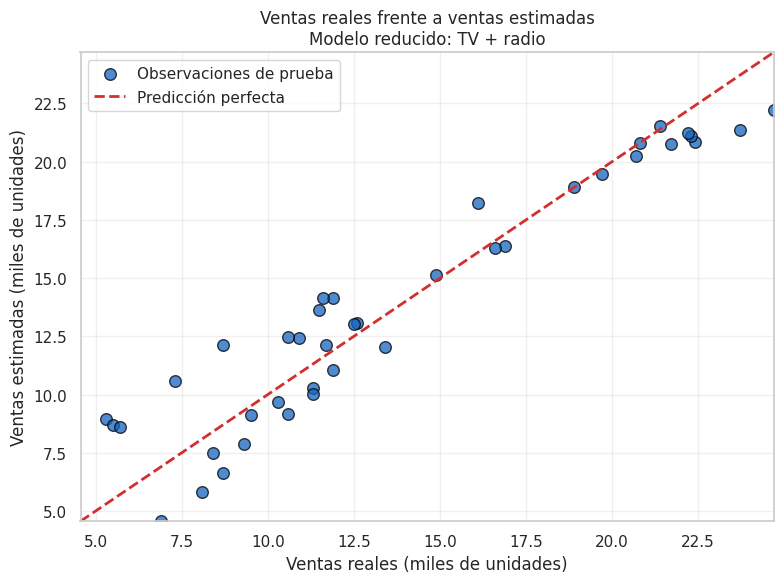

In [13]:
limite_minimo = min(
    y_prueba.min(),
    y_pred_reducido.min()
)
limite_maximo = max(
    y_prueba.max(),
    y_pred_reducido.max()
)
plt.figure(figsize=(8, 6))

plt.scatter(
    y_prueba,
    y_pred_reducido,
    color="#1565C0",
    edgecolor="black",
    alpha=0.75,
    s=70,
    label="Observaciones de prueba"
)
plt.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    color="#D32F2F",
    linestyle="--",
    linewidth=2,
    label="Predicción perfecta"
)
plt.xlabel("Ventas reales (miles de unidades)")
plt.ylabel("Ventas estimadas (miles de unidades)")
plt.title("Ventas reales frente a ventas estimadas\nModelo reducido: TV + radio")
plt.xlim(limite_minimo, limite_maximo)
plt.ylim(limite_minimo, limite_maximo)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de la gráfica

La mayoría de las observaciones se encuentra relativamente cerca de la línea de predicción perfecta, lo cual indica que las ventas estimadas por el modelo reducido son próximas a las ventas reales.

Los puntos ubicados por encima de la línea representan observaciones en las que el modelo sobreestimó las ventas, mientras que los puntos ubicados por debajo corresponden a observaciones en las que el modelo las subestimó.

También se observan algunas predicciones más alejadas de la línea, especialmente entre los valores bajos e intermedios de ventas. Esto demuestra que, aunque el modelo presenta un buen desempeño general, sus predicciones no son exactas para todas las observaciones.

El comportamiento gráfico es coherente con el valor obtenido:

$$
R^2=0.9006
$$

El modelo explica una proporción alta de la variabilidad observada en las ventas del conjunto de prueba.

## Conclusión del laboratorio

En este laboratorio se construyó un modelo de regresión lineal múltiple para estimar las ventas a partir de la inversión realizada en televisión, radio y prensa.

El modelo completo mostró que `TV` y `radio` presentaban asociaciones positivas y estadísticamente significativas con las ventas. En cambio, `newspaper` obtuvo un valor \(p=0.6958\), por lo que no se encontró evidencia suficiente de un aporte lineal adicional después de controlar las demás variables.

Posteriormente se compararon tres modelos:

- modelo simple con `TV`;
- modelo reducido con `TV` y `radio`;
- modelo completo con `TV`, `radio` y `newspaper`.

El modelo reducido obtuvo el mejor desempeño predictivo:

$$
R^2=0.9006
$$

$$
MAE=1.4443
$$

$$
MSE=3.1379
$$

$$
RMSE=1.7714
$$

La ecuación seleccionada fue:

$$
\widehat{\text{sales}}
=
3.0283
+0.0447(\text{TV})
+0.1907(\text{radio})
$$

Esto significa que, manteniendo constante la inversión en radio, cada mil dólares adicionales invertidos en televisión se asocian con un aumento estimado de aproximadamente **44.7 unidades vendidas**. Manteniendo constante la inversión en televisión, cada mil dólares adicionales invertidos en radio se asocian con un aumento estimado de aproximadamente **190.7 unidades vendidas**.

Se seleccionó el modelo reducido porque presentó el mayor \(R^2\), los menores errores y utilizó menos variables que el modelo completo. La gráfica de valores reales frente a estimados confirmó que la mayoría de las predicciones se encuentra cerca de la línea ideal, aunque persisten errores en algunas observaciones.

Los resultados corresponden al conjunto de datos y a la división entrenamiento-prueba utilizados. No demuestran relaciones causales ni garantizan el mismo desempeño con nuevos datos.